# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Ahmad Zaki Fauzan Nabil | 5054251044 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Informasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe(include='all'))

print("\nJumlah Missing Value Awal:")
print(df.isnull().sum())

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN



Jumlah Missing Value Awal:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


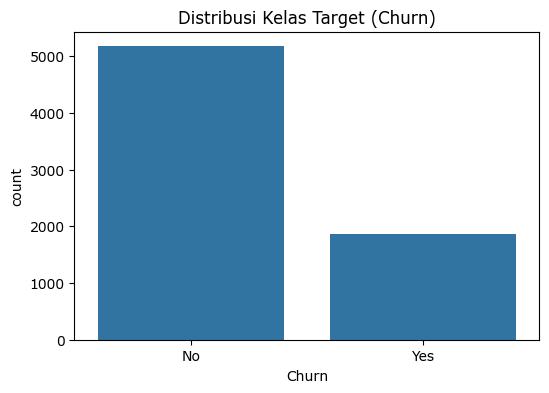

Proporsi Churn:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribusi Kelas Target (Churn)')
plt.show()

print("Proporsi Churn:")
print(df['Churn'].value_counts(normalize=True))

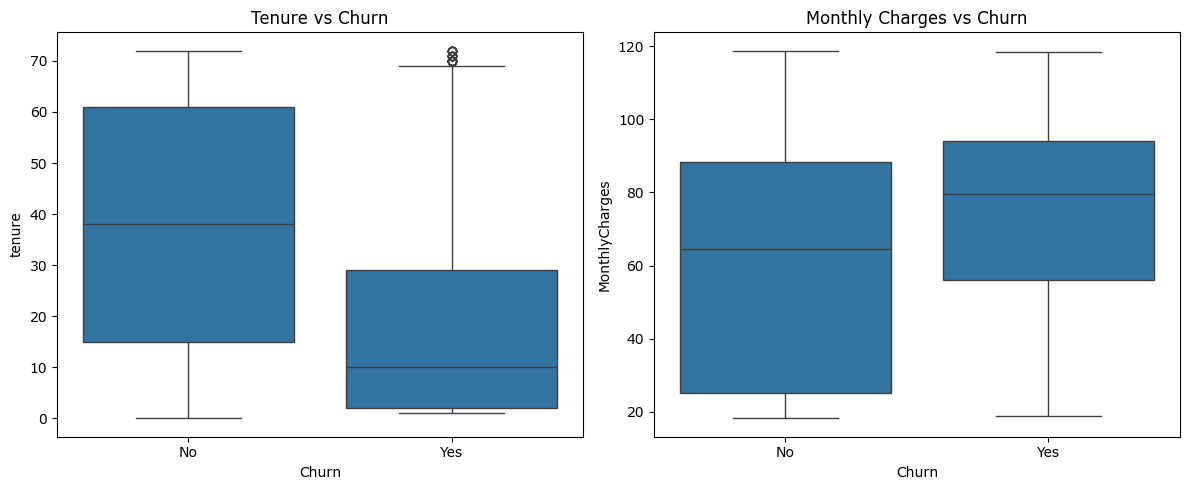

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
# Perlu ubah TotalCharges menjadi numerik terlebih dahulu untuk visualisasi
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [5]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df.fillna({'TotalCharges': df['TotalCharges'].median()}, inplace=True)
print("Missing values setelah penanganan:", df['TotalCharges'].isnull().sum())

Missing values setelah penanganan: 0


In [6]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
df = df.drop('customerID', axis=1)
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [7]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)

Ukuran X_train: (5634, 30)
Ukuran X_test: (1409, 30)


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [8]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [9]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
mlp_base = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=200, random_state=42)
mlp_base.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [10]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_base = mlp_base.predict(X_test_scaled)
print("Akurasi model dasar:", accuracy_score(y_test, y_pred_base))

Akurasi model dasar: 0.801277501774308


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [11]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
activations = ['relu', 'tanh', 'logistic']
models_act = {}

for act in activations:
    model = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=200, random_state=42)
    model.fit(X_train_scaled, y_train)
    models_act[act] = model

In [12]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.
acc_results = []
for act, model in models_act.items():
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    acc_results.append({'Activation': act, 'Accuracy': acc})

df_acc = pd.DataFrame(acc_results)
display(df_acc)

best_activation = df_acc.loc[df_acc['Accuracy'].idxmax(), 'Activation']
print("Aktivasi terbaik:", best_activation)

,Activation,Accuracy
0,relu,0.801278
1,tanh,0.800568
2,logistic,0.801278


Aktivasi terbaik: relu


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [13]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
architectures = [(2,), (5,), (10,), (50,), (100, 50)]
models_arch = {}

for arch in architectures:
    model = MLPClassifier(hidden_layer_sizes=arch, activation=best_activation, max_iter=200, random_state=42)
    model.fit(X_train_scaled, y_train)
    models_arch[str(arch)] = model

In [14]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_accs = []
test_accs = []
arch_labels = [str(a) for a in architectures]

for arch in arch_labels:
    model = models_arch[arch]
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    
    train_accs.append(accuracy_score(y_train, train_pred))
    test_accs.append(accuracy_score(y_test, test_pred))
    
df_arch = pd.DataFrame({
    'Arsitektur': arch_labels,
    'Train Accuracy': train_accs,
    'Test Accuracy': test_accs
})
display(df_arch)

,Arsitektur,Train Accuracy,Test Accuracy
0,"(2,)",0.806532,0.797729
1,"(5,)",0.807952,0.799858
2,"(10,)",0.815406,0.801278
3,"(50,)",0.832801,0.786373
4,"(100, 50)",0.924388,0.767921


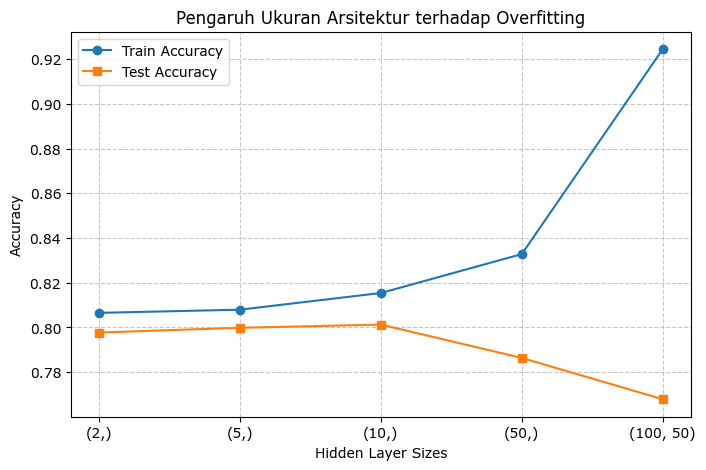

In [15]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(8, 5))
plt.plot(arch_labels, train_accs, marker='o', label='Train Accuracy')
plt.plot(arch_labels, test_accs, marker='s', label='Test Accuracy')
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Accuracy')
plt.title('Pengaruh Ukuran Arsitektur terhadap Overfitting')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Evaluasi Model

In [16]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

# Best dari 3.2 (Aktivasi)
best_model_act = models_act[best_activation]
y_pred_act = best_model_act.predict(X_test_scaled)

# Best dari 3.3 (Arsitektur - pilih yang test accuracy-nya paling tinggi)
best_arch_label = arch_labels[np.argmax(test_accs)]
best_model_arch = models_arch[best_arch_label]
y_pred_arch = best_model_arch.predict(X_test_scaled)

def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

metrics_df = pd.DataFrame({
    f'Best Act ({best_activation})': get_metrics(y_test, y_pred_act),
    f'Best Arch ({best_arch_label})': get_metrics(y_test, y_pred_arch)
}).T
display(metrics_df)

,Accuracy,Precision,Recall,F1-Score
Best Act (relu),0.801278,0.646875,0.553476,0.596542
"Best Arch ((10,))",0.801278,0.646875,0.553476,0.596542


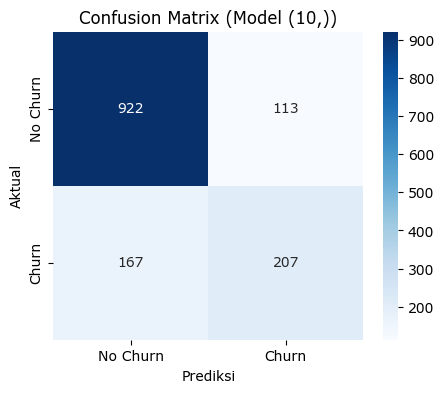

In [17]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
cm = confusion_matrix(y_test, y_pred_arch)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix (Model {best_arch_label})')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

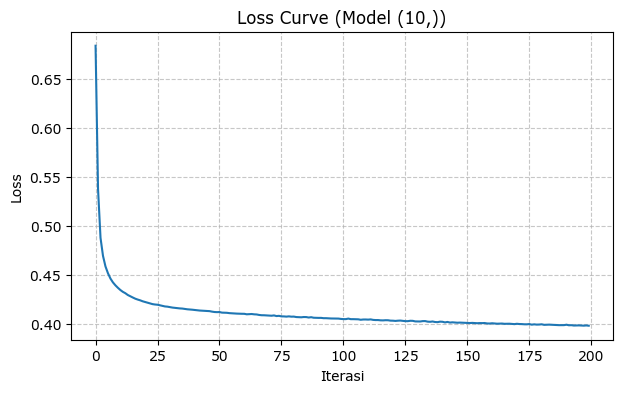

In [18]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.
plt.figure(figsize=(7, 4))
plt.plot(best_model_arch.loss_curve_)
plt.title(f'Loss Curve (Model {best_arch_label})')
plt.xlabel('Iterasi')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. Analisis

### Analisis Hasil Eksperimen

- **Perbandingan Fungsi Aktivasi:** Berdasarkan hasil eksperimen pada arsitektur `(10,)`, akurasi yang didapatkan dari fungsi aktivasi ReLU (sekitar 80.13%), Tanh (sekitar 80.06%), dan Logistic (sekitar 80.13%) tidak menunjukkan perbedaan yang sangat drastis. Ketiganya memberikan performa yang cukup seimbang. Hal ini umumnya terjadi karena dengan arsitektur model yang sederhana, representasi non-linear yang dihasilkan ketiga fungsi aktivasi tersebut masih mampu mengekstraksi informasi pola dasar secara serupa dari dataset ini.
- **Eksperimen Regularisasi (Ukuran Arsitektur):** Dari rentetan percobaan dengan variasi `hidden_layer_sizes` mulai dari (2,), (5,), (10,), (50,), hingga (100, 50), terlihat bahwa gejala *overfitting* mulai lebih kentara saat kapasitas model dinaikkan, terutama pada arsitektur yang lebih kompleks seperti (50,) dan (100, 50). Hal ini dapat diamati dengan jelas pada grafik komparasi akurasi: akurasi pada data training terus mengalami peningkatan seiring bertambahnya neuron, sedangkan akurasi testing perlahan mulai stagnan dan bahkan menurun. Kondisi ini memperlihatkan adanya celah (gap) performa yang membesar, yang merupakan indikasi kuat dari *overfitting*.
- **Loss Curve:** Mengamati grafik *loss curve* pada model terbaik, garis grafik umumnya telah menunjukkan pergerakan yang melandai (konvergen) menjelang iterasi akhir. Namun, jika didapati kurva masih menukik turun dengan tajam pada saat batas `max_iter` tercapai, langkah utama yang harus dilakukan adalah memperbesar nilai parameter `max_iter` supaya algoritma optimisasi memiliki kesempatan waktu tambahan untuk mencapai titik minimum lokalnya. Alternatif lain adalah mengatur nilai parameter *learning rate* menjadi lebih besar atau menerapkan *early stopping* agar model dapat berhenti secara ideal.

# 6. Kesimpulan dan Saran

### Kesimpulan

Melalui proses eksplorasi dan pembangunan model Artificial Neural Network (ANN) untuk dataset *Telco Customer Churn*, dapat disimpulkan bahwa:
1. Model ANN mampu memprediksi klasifikasi *churn* pelanggan dengan akurasi yang cukup baik yaitu di kisaran 80%.
2. Pemilihan jenis fungsi aktivasi pada tingkat arsitektur MLP yang tidak terlalu dalam tidak terlalu memengaruhi skor performa secara masif, dengan hasil ReLU dan Logistic cenderung sedikit lebih optimal.
3. Menambah jumlah neuron dan *hidden layer* (memperbesar arsitektur) memang berpotensi menaikkan akurasi pada fase training, namun berisiko tinggi memicu fenomena *overfitting*, sehingga model menjadi terlalu menghafal *noise* dan kurang andal dalam menggeneralisasi data baru (testing).

### Saran

Untuk penelitian atau perbaikan model di tahap selanjutnya, beberapa saran pengerjaan yang direkomendasikan adalah:
- Menggunakan teknik pencarian hyperparameter (*Hyperparameter Tuning*) secara sistematis, seperti `GridSearchCV` atau `RandomizedSearchCV`, guna menemukan konfigurasi terbaik untuk ukuran arsitektur, parameter regularisasi `alpha`, serta *learning rate*.
- Menerapkan penanganan dataset imbalanced, mengingat jumlah kelas target 'Churn' yang tidak seimbang, misalnya dengan mempraktikkan metode oversampling seperti SMOTE atau undersampling, sehingga performa (khususnya *recall* kelas minoritas) dapat ditingkatkan.
- Mengaktifkan mode *early stopping* (`early_stopping=True`) selama inisiasi MLPClassifier. Langkah preventif ini berguna untuk menyetop siklus *training* secara instan saat kualitas model terhadap data validasi sudah tidak mengalami eskalasi, yang mana sangat efektif menanggulangi masalah *overfitting*.